# SEMANA 3

Empezamos importando las librerias y 

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
baseball = pd.read_csv('baseball_construccion.csv')
explotacion = pd.read_csv('baseball_explotacion.csv')


In [160]:
baseball = baseball.drop("year",axis = 1)
months = {"JAN": 1, "FEB": 2, "MAR": 3, "APR": 4, "MAY": 5, "JUN": 6, "JUL": 7, "AUG": 8, "SEP": 9, "OCT": 10, "NOV": 11, "DEC": 12}
baseball["month"] = baseball["month"].map(months)
days = {"Monday": 1, "Tuesday": 2, "Wednesday": 3, "Thursday": 4, "Friday": 5, "Saturday": 6, "Sunday": 7}
baseball["day_of_week"] = baseball["day_of_week"].map(days)
baseball = pd.get_dummies(baseball,columns=["skies"])
baseball["day_night"] = baseball["day_night"].map({"Day" : True,"Night":False})
baseball["cap"] = baseball["cap"].map({"YES" : True,"NO":False})
baseball["shirt"] = baseball["shirt"].map({"YES" : True,"NO":False})
baseball["fireworks"] = baseball["fireworks"].map({"YES" : True,"NO":False})
baseball["bobblehead"] = baseball["bobblehead"].map({"YES" : True,"NO":False})
baseball["hum>average"] = baseball["hum>average"].map({"YES" : True,"NO":False})
baseball = pd.get_dummies(baseball, columns=["home_team","opponent"])

baseball


,Unnamed: 0,month,day,attend,day_of_week,temp,day_night,cap,shirt,fireworks,...,opponent_Philadelphia Phillies,opponent_Pittsburgh Pirates,opponent_San Diego Padres,opponent_San Francisco Giants,opponent_Seattle Mariners,opponent_St. Louis Cardinals,opponent_Tampa Bay Rays,opponent_Texas Rangers,opponent_Toronto Blue Jays,opponent_Washington Nationals
0,0,4,6,32741,5,59,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,4,7,22072,6,63,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,4,8,10317,7,68,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3,4,9,17835,1,65,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4,4,10,17261,2,62,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2176,2408,9,6,15713,4,79,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2177,2409,9,7,19973,5,83,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2178,2410,9,8,20202,6,83,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2179,2411,9,9,17077,7,74,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [161]:
explotacion = explotacion.drop("year",axis = 1)
months = {"JAN": 1, "FEB": 2, "MAR": 3, "APR": 4, "MAY": 5, "JUN": 6, "JUL": 7, "AUG": 8, "SEP": 9, "OCT": 10, "NOV": 11, "DEC": 12}
explotacion["month"] = explotacion["month"].map(months)
days = {"Monday": 1, "Tuesday": 2, "Wednesday": 3, "Thursday": 4, "Friday": 5, "Saturday": 6, "Sunday": 7}
explotacion["day_of_week"] = explotacion["day_of_week"].map(days)
explotacion = pd.get_dummies(explotacion,columns=["skies"])
explotacion["day_night"] = explotacion["day_night"].map({"Day" : True,"Night":False})
explotacion["cap"] = explotacion["cap"].map({"YES" : True,"NO":False})
explotacion["shirt"] = explotacion["shirt"].map({"YES" : True,"NO":False})
explotacion["fireworks"] = explotacion["fireworks"].map({"YES" : True,"NO":False})
explotacion["bobblehead"] = explotacion["bobblehead"].map({"YES" : True,"NO":False})
explotacion["hum>average"] = explotacion["hum>average"].map({"YES" : True,"NO":False})
explotacion = pd.get_dummies(explotacion, columns=["home_team","opponent"])
explotacion


,Unnamed: 0,month,day,attend,day_of_week,temp,day_night,cap,shirt,fireworks,...,opponent_Philadelphia Phillies,opponent_Pittsburgh Pirates,opponent_San Diego Padres,opponent_San Francisco Giants,opponent_Seattle Mariners,opponent_St. Louis Cardinals,opponent_Tampa Bay Rays,opponent_Texas Rangers,opponent_Toronto Blue Jays,opponent_Washington Nationals
0,71,9,12,NaN,3,77,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,72,9,13,NaN,4,76,True,False,True,False,...,False,False,False,False,False,False,True,False,False,False
2,73,9,24,NaN,1,65,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,74,9,25,NaN,2,72,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,75,9,26,NaN,3,81,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,2416,9,23,NaN,7,67,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
236,2417,9,24,NaN,1,66,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
237,2418,10,1,NaN,1,64,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
238,2419,10,2,NaN,2,70,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


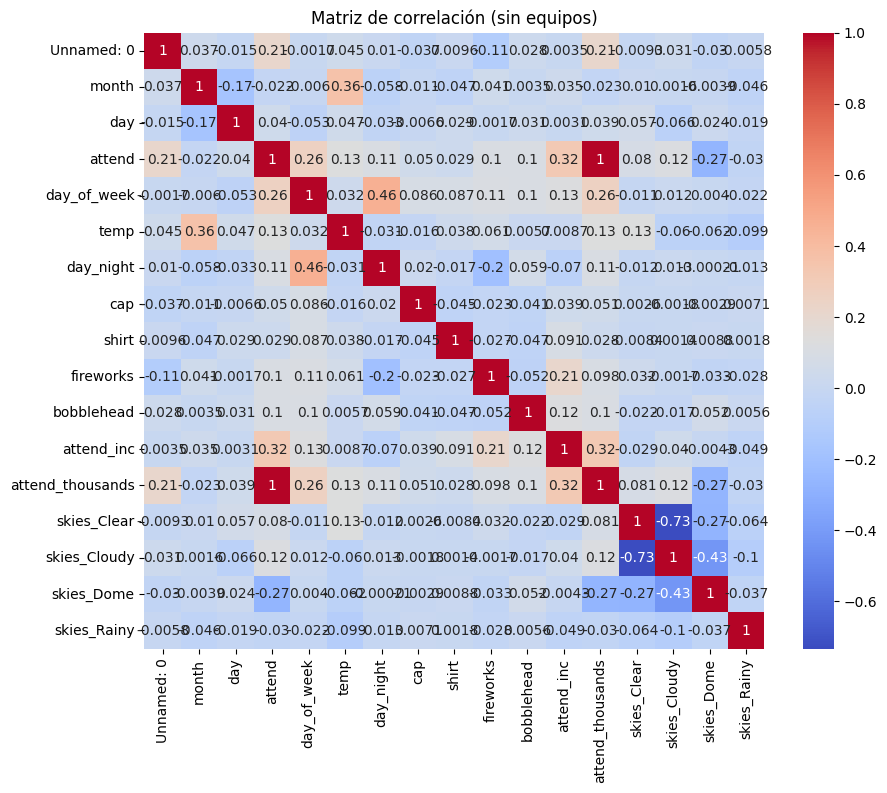

In [162]:
# Ahora vamos a realizar el mapa de correlación a ver que variables estan mas relacionadas entre si

###plt.figure(figsize=(100,60))
###sns.heatmap(baseball.corr(numeric_only=True), annot=True)
###plt.title("Correlacion")
###plt.show()

#Si hacemos one hot en opponent y en home team se crean muchas variables booleanas que impiden la correcta interpretacion de la relacion que hay entre ellos 
corr = baseball.drop(columns=[c for c in baseball.columns if c.startswith("home_team_") or c.startswith("opponent_")])
corr = corr.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación (sin equipos)")
plt.show()


Vemos que, por ejemplo day_ of_week esta bastante relacionada con attend

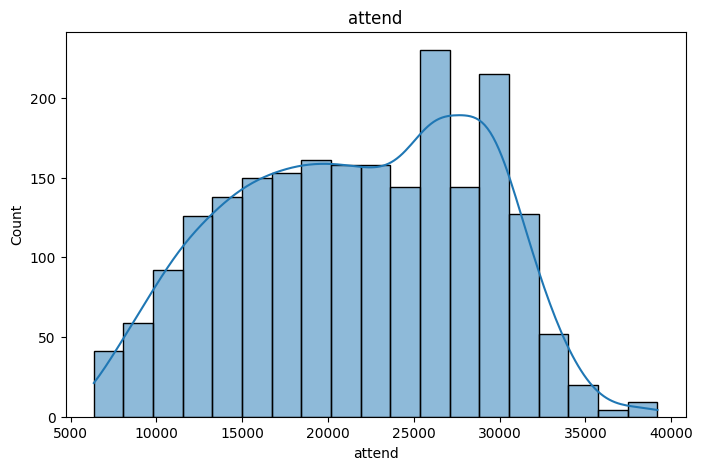

In [163]:
#Ahora con la variable objetivo
plt.figure(figsize=(8,5))
sns.histplot(baseball["attend"], kde=True)
plt.title("attend")
plt.show()

Al analizar la matriz de correlación, observamos que las variables con mayor relación lineal con attend son attend_inc (r = 0.32) y day_of_week (r = 0.26). También se observa una ligera relación con la temperatura y con si el evento es de día o de noche. Por tanto, se seleccionan estas variables como las más relevantes para el modelo, junto con las binarias cap, shirt, fireworks, bobblehead y las skies_, que podrían influir indirectamente en la asistencia.
Ahora procederemos con el modelo, partiendo por separar la variable objetivo y lo demas

In [164]:
y = baseball['attend']
X = baseball.drop(columns=['attend','attend_thousands'])



#Convertimos todas las columnas a valores numéricos.
# LinearRegression devuelve error si aparece algún NaN, entonces los pocos que quedan se reemplazan con 0 que al ser tan pocos no llegara
#nunca a que el error relativo medio supere mucho el 1.3 que ha dado.
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)


#Dividimos entre dats de entrenamiento y datos de validacion, repartiendo un 0.2 a la validaciony 0.8 al antrenamiento. 
# Además las columnas dadas en shape se ajustan mas o menos a ese 80/20

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr.shape, X_va.shape

((1744, 76), (437, 76))

In [165]:
#Creamos y entrenamos el modelo de regresion lineal
modelo = LinearRegression()
modelo.fit(X_tr, y_tr)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [166]:
y_pred = modelo.predict(X_va)

## ERM
error_relativo_medio = 100 * np.mean(np.abs(y_pred - y_va) / y_va)
print(error_relativo_medio)

13.937047164339564


home_team_Baltimore Orioles        198595.945056
home_team_Washington Nationals     193533.365455
home_team_St. Louis Cardinals      187600.011237
home_team_San Francisco Giants     176431.299525
home_team_Boston Red Sox           176238.814167
home_team_Chicago White Sox        172812.600314
home_team_Cleveland Indians        161669.058484
home_team_San Diego Padres         151973.484065
home_team_Pittsburgh Pirates       137811.526309
home_team_Philadelphia Phillies    137229.318655
home_team_Detroit Tigers           136946.906133
home_team_Houston Astros           134644.634029
home_team_Kansas City Royals       120951.677600
home_team_New York Mets            112389.573130
home_team_Milwaukee Brewers        103772.840362
dtype: float64
bobblehead      2747.107804
month           2060.298948
fireworks       1928.135563
cap             1376.433545
day_night        935.103067
shirt            793.753217
day_of_week      636.485175
hum>average      328.465448
skies_Rainy      208.69357

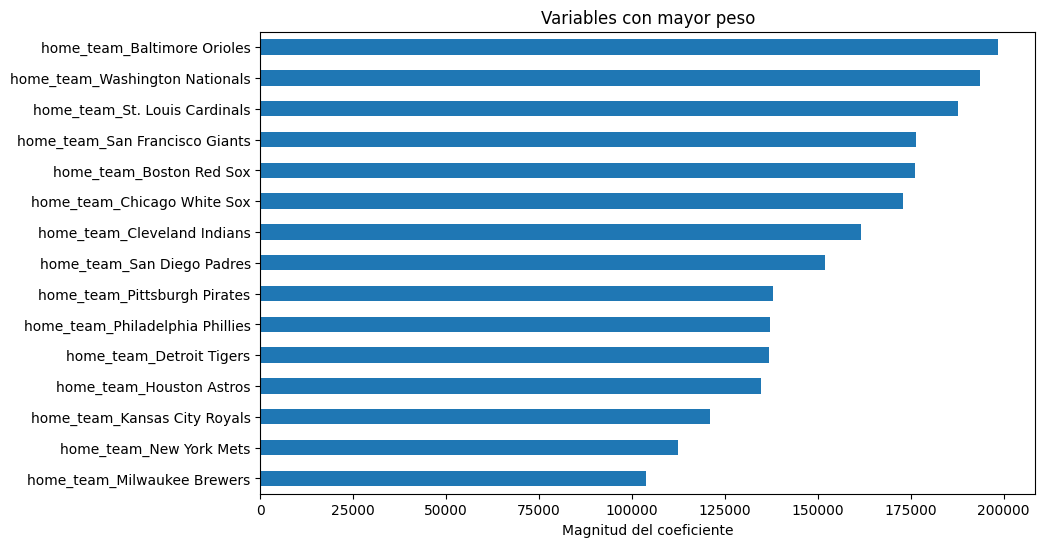

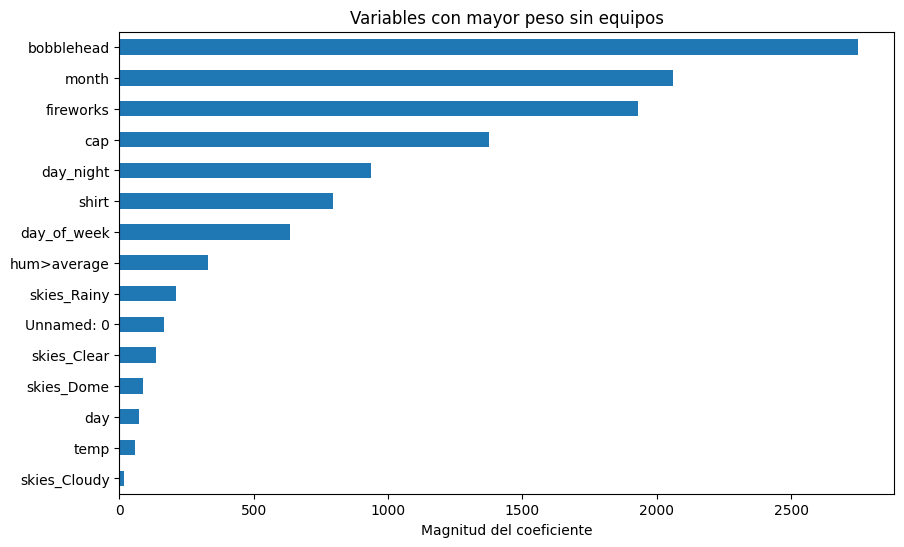

In [167]:
#Guardamos los coeficientes del modelo
coeficientes = pd.Series(modelo.coef_, index=X_tr.columns).abs().sort_values(ascending=False)

# Mostramos las 15 variables con mayor influencia
print(coeficientes.head(15))

#Se puede ver que hay los mas influyentes son dependiendo de los equipos que jueguen, los másfamosos atraeran mas gente.
#Filtramos para quitar las variables de equipos
scoeficientes = pd.Series(modelo.coef_, index=X_tr.columns)
scoeficientes = scoeficientes[~scoeficientes.index.str.startswith("home_team_")]
scoeficientes = scoeficientes[~scoeficientes.index.str.startswith("opponent_")]
scoeficientes = scoeficientes.abs().sort_values(ascending=False)

# Mostramos las 15 variables no relacionadas con equipos
print(scoeficientes.head(15))





#Grafico de las 15 más influyentes
plt.figure(figsize=(10,6))
coeficientes.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Variables con mayor peso")
plt.xlabel("Magnitud del coeficiente")
plt.show()

#Gráfico de las 15 más influyentes sin equipos
plt.figure(figsize=(10,6))
scoeficientes.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Variables con mayor peso sin equipos")
plt.xlabel("Magnitud del coeficiente")
plt.show()



#Claramente attend thousands t¡da la primera ya que son lo mismo




**Vamos con el explotación**
Los datos estaban descuadrados, y con indices desparejos, por lo tanto vamos a reindexarlos

In [168]:
explotacion = explotacion.reindex(columns=X_tr.columns, fill_value=0)

month, day of week

In [169]:
#Para evitar errores con Nan, repito lo que hice antes con el otro dataset para que linear regression no falle:
explotacion = explotacion.apply(pd.to_numeric, errors='coerce').fillna(0)


### Entonces, vamos ya a ver las predicciones evitando valotres negativos:
predicciones = modelo.predict(explotacion)
predicciones = np.maximum(0, predicciones)



#Con to_csv generamos el csv con las predicciones deseadas
pd.DataFrame({"attend": np.rint(predicciones).astype(int)}).to_csv("predicciones1.csv", index=False)
